# Open Notebook & Additional Resources

<a target="_blank" href="https://colab.research.google.com/github/Nicolepcx/hands-on-multimodal-AI/blob/main/hands-on/DEMO_session_01_multimodal_tokens_and_embeddings.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>
<a target="_blank" href="https://www.oreilly.com/library/view/transformers-the-definitive/9781098167004/">
  <img src="https://img.shields.io/badge/AI%20Agents%20Book-Read%20on%20O'Reilly-d40101?style=flat" alt="Transformers: The Definitive Guide"/>
</a>




# About This Notebook: Multimodal Mechanistic Interpretability

This notebook uses **Model:** [`Qwen/Qwen2.5-Omni-3B`](https://huggingface.co/Qwen/Qwen2.5-Omni-3B) to show the multimodal mapping and unifying in transformers. This notebook focuses on *how* the model thinks (internal state). By probing the **residual stream** across every layer, we can prove whether the model is truly "understanding" the video or simply reacting to statistical noise.


The processor builds a text token sequence that includes special **placeholder tokens**, and provides modality tensors separately. The model encodes the modality tensors into `hidden_size` vectors and **injects** them at the placeholder positions before running the **shared decoder stack**.


## How the Pipeline Works

```
Processor output                       Model internals
─────────────────                      ───────────────

 input_ids                              embed_tokens
 ┌──────┬────────────┬──────┐           ┌──────┬────────────┬──────┐
 │ text │ <img_pad>  │ text │    →      │ text │  vision    │ text │
 │ tok  │    × N     │ tok  │           │ emb  │  emb (N)   │ emb  │
 └──────┴────────────┴──────┘           └──────┴─────┬──────┴──────┘
                                                      │
 pixel_values ──→ vision encoder ──→ projection ──────┘  (replace placeholders)
 image_grid_thw                          ↓
                                     ┌─────────────────────────────┐
 audio features ──→ audio encoder ──→│   Shared Decoder Stack      │
                                     │   (same attention for ALL   │
                                     │    positions, all layers)   │
                                     └─────────────┬───────────────┘
                                                   ↓
                                     hidden_size vectors at every position
```

| Step | What happens | Result |
|------|-------------|--------|
| **A. Processor** | Tokenises text, inserts placeholder tokens, provides modality tensors separately | `input_ids` + `pixel_values` / audio features |
| **B. Encoders** | Vision / audio encoder + linear projection | Sequences of `hidden_size` vectors |
| **C. Decoder** | Shared transformer layers run on the interleaved sequence | All modalities interact via the **same** attention blocks |

In [ ]:
!pip -q install -U "transformers==4.57.3" safetensors
!pip install -U "qwen-omni-utils[decord]" accelerate soundfile

In [ ]:
import os, base64, subprocess
import gdown
from IPython.display import HTML, display
from PIL import Image
import warnings, torch
warnings.filterwarnings("ignore")

from transformers import Qwen2_5OmniForConditionalGeneration, Qwen2_5OmniProcessor
from qwen_omni_utils import process_mm_info

import numpy as np
import matplotlib.pyplot as plt
import torch



# Fetch a short video and extract one frame


Downloading...
From: https://drive.google.com/uc?id=17ZeTnfVoCC-uEioa5uQgTwPR_DFeD5Cd
To: /content/video_from_drive.mp4
100%|██████████| 285k/285k [00:00<00:00, 92.3MB/s]


Video: video_from_drive.mp4 (0.3 MB)
Frame: frame_from_video.jpg


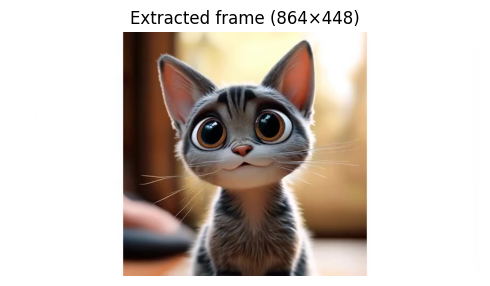

In [ ]:

file_id = "17ZeTnfVoCC-uEioa5uQgTwPR_DFeD5Cd"
video_path = "video_from_drive.mp4"
frame_path = "frame_from_video.jpg"

if not os.path.exists(video_path):
    gdown.download(f"https://drive.google.com/uc?id={file_id}", video_path, quiet=False)
assert os.path.exists(video_path), "Video download failed"

subprocess.run(
    ["ffmpeg", "-y", "-i", video_path, "-vframes", "1", "-q:v", "2", frame_path, "-loglevel", "quiet"],
    check=True
)
assert os.path.exists(frame_path), "Frame extraction failed"

print("Video:", video_path, f"({os.path.getsize(video_path)/1e6:.1f} MB)")
print("Frame:", frame_path)

with open(video_path, "rb") as f:
    data_url = "data:video/mp4;base64," + base64.b64encode(f.read()).decode()
display(HTML(f'<video controls width="480" src="{data_url}"></video>'))

frame_img = Image.open(frame_path)
fig, ax = plt.subplots(figsize=(5, 3))
ax.imshow(frame_img)
ax.set_title(f"Extracted frame ({frame_img.size[0]}×{frame_img.size[1]})")
ax.axis("off")
plt.tight_layout()
plt.show()

# Install and load Qwen2.5 Omni

In [ ]:


MODEL_ID = "Qwen/Qwen2.5-Omni-3B"

DEFAULT_OMNI_SYSTEM = (
    "You are Qwen, a virtual human developed by the Qwen Team, Alibaba Group, "
    "capable of perceiving auditory and visual inputs, as well as generating text and speech."
)

processor = Qwen2_5OmniProcessor.from_pretrained(MODEL_ID)
model = Qwen2_5OmniForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype="auto",
    device_map="auto",
)
model.disable_talker()
model.eval()

tokenizer = processor.tokenizer

TOK_IMAGE = "<|IMAGE|>"
TOK_AUDIO = "<|AUDIO|>"

image_tok_id = tokenizer.convert_tokens_to_ids(TOK_IMAGE)
audio_tok_id = tokenizer.convert_tokens_to_ids(TOK_AUDIO)

embed_layer = model.thinker.model.embed_tokens
hidden_size = embed_layer.embedding_dim

print("Device:", model.device)
print("dtype:", next(model.parameters()).dtype)
print("hidden_size:", hidden_size)
print("image_tok_id:", image_tok_id, TOK_IMAGE)
print("audio_tok_id:", audio_tok_id, TOK_AUDIO)
print("Special tokens map:", tokenizer.special_tokens_map)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 120.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 121.2 MB/s eta 0:00:00


preprocessor_config.json:   0%|          | 0.00/667 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Qwen2_5OmniToken2WavModel does not support eager attention implementation, fall back to sdpa


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

spk_dict.pt:   0%|          | 0.00/260k [00:00<?, ?B/s]

Device: cuda:0
dtype: torch.bfloat16
hidden_size: 2048
image_tok_id: 151655 <|IMAGE|>
audio_tok_id: 151646 <|AUDIO|>
Special tokens map: {'eos_token': '<|im_end|>', 'pad_token': '<|endoftext|>', 'additional_special_tokens': ['<|im_start|>', '<|im_end|>', '<|AUDIO|>', '<|audio_bos|>', '<|audio_eos|>', '<|box_end|>', '<|quad_start|>', '<|quad_end|>', '<|vision_bos|>', '<|vision_eos|>', '<|vision_pad|>', '<|IMAGE|>', '<|VIDEO|>'], 'image_token': '<|IMAGE|>', 'audio_token': '<|AUDIO|>', 'video_token': '<|VIDEO|>', 'vision_bos_token': '<|vision_bos|>', 'vision_eos_token': '<|vision_eos|>', 'audio_bos_token': '<|audio_bos|>', 'audio_eos_token': '<|audio_eos|>'}


# Helpers: build inputs, generation, hidden states, masks, plots

In [ ]:

def pretty_token(tok: str) -> str:
    return tok.replace("Ġ", " ").replace("▁", " ")

def show_inputs(inputs, title):
    print("\n" + "=" * 72)
    print(title)
    print("=" * 72)
    for k, v in inputs.items():
        if hasattr(v, "shape"):
            print(f"{k:28s} shape={tuple(v.shape)!s:>18s}  dtype={getattr(v, 'dtype', None)}")
        else:
            print(f"{k:28s} type={type(v).__name__}")

def build_inputs(conversation, use_audio_in_video: bool):
    text = processor.apply_chat_template(
        conversation,
        tokenize=False,
        add_generation_prompt=True,
        system_prompt=DEFAULT_OMNI_SYSTEM,
    )
    audios, images, videos = process_mm_info(conversation, use_audio_in_video=use_audio_in_video)

    kwargs = dict(
        text=text,
        return_tensors="pt",
        padding=True,
        use_audio_in_video=use_audio_in_video,
    )
    if audios is not None:
        kwargs["audio"] = audios
    if images is not None:
        kwargs["images"] = images
    if videos is not None:
        kwargs["videos"] = videos

    inputs = processor(**kwargs)
    return inputs.to(model.device).to(model.dtype)

def generate_answer_only(inputs, max_new_tokens=256):
    with torch.no_grad():
        out_ids = model.generate(**inputs, return_audio=False, max_new_tokens=max_new_tokens)
    prompt_len = inputs["input_ids"].shape[1]
    gen_only = out_ids[:, prompt_len:]
    return processor.batch_decode(
        gen_only,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0].strip()

def forward_hidden_states(inputs):
    with torch.no_grad():
        out = model.thinker(**inputs, output_hidden_states=True, return_dict=True)
    return out.hidden_states

def masks_from_inputs(inputs):
    ids = inputs["input_ids"][0]
    is_vision = (ids == image_tok_id)
    is_audio  = (ids == audio_tok_id)
    is_text   = (~is_vision) & (~is_audio)
    return ids, is_text, is_vision, is_audio

def collect_norms(h_2d: torch.Tensor, mask: torch.Tensor):
    x = h_2d[mask].float()
    if x.numel() == 0:
        return torch.empty(0, dtype=torch.float32)
    return torch.linalg.norm(x, dim=-1).detach().cpu()

def plot_norm_histograms(norms_dict, title):
    colors = {"Text": "#000000", "Vision": "#808080", "Audio": "#E51837"}
    mods = [m for m in ["Text", "Vision", "Audio"] if m in norms_dict]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
    axes[0].set_title("Layer 0")
    axes[1].set_title("Final layer")

    all_vals = []
    for m in mods:
        all_vals.append(norms_dict[m]["L0"].numpy())
        all_vals.append(norms_dict[m]["Final"].numpy())
    all_vals = np.concatenate([v for v in all_vals if v.size > 0], axis=0)
    if all_vals.size == 0:
        print("No norms to plot.")
        return

    bins = np.histogram_bin_edges(all_vals, bins=40)

    for ax, key in [(axes[0], "L0"), (axes[1], "Final")]:
        for m in mods:
            vals = norms_dict[m][key].numpy()
            if vals.size == 0:
                continue
            ax.hist(
                vals, bins=bins, density=True, alpha=0.35,
                color=colors[m], label=m, edgecolor="white", linewidth=0.4
            )
        ax.set_xlabel("L2 norm")
        ax.grid(True, alpha=0.15)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel("Density")
    axes[1].legend(frameon=False, loc="best")
    fig.suptitle(title, y=1.03)
    plt.tight_layout()
    plt.show()

In [ ]:

def _masked_rows(h_2d: torch.Tensor, mask_1d: torch.Tensor) -> torch.Tensor:
    x = h_2d[mask_1d].float()
    return x

def centroid_direction(h_2d: torch.Tensor, mask_1d: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Robust centroid direction:
    1) normalize each token vector to unit length
    2) average
    3) normalize again

    Returns a 1D unit vector. If mask empty, returns None.
    """
    x = _masked_rows(h_2d, mask_1d)
    if x.numel() == 0:
        return None
    x = x / (x.norm(dim=-1, keepdim=True) + eps)
    c = x.mean(dim=0)
    c = c / (c.norm() + eps)
    return c

def cosine(u: torch.Tensor, v: torch.Tensor, eps: float = 1e-8) -> float:
    if (u is None) or (v is None):
        return float("nan")
    return float(torch.dot(u, v) / ((u.norm() + eps) * (v.norm() + eps)))

def token_to_centroid_cosines(h_2d: torch.Tensor, token_mask: torch.Tensor, centroid: torch.Tensor, eps: float = 1e-8):
    """
    Cosine for each token vector vs a centroid direction.
    Returns a 1D CPU numpy array.
    """
    x = _masked_rows(h_2d, token_mask)
    if x.numel() == 0 or centroid is None:
        return np.array([])
    x = x / (x.norm(dim=-1, keepdim=True) + eps)
    c = centroid / (centroid.norm() + eps)
    sims = (x @ c).detach().cpu().numpy()
    return sims

def plot_centroid_cosines(title, layer_names, values):
    fig, ax = plt.subplots(figsize=(5.5, 3.8))
    ax.bar(layer_names, values)
    ax.set_ylim(-1.0, 1.0)
    ax.set_ylabel("Cosine similarity")
    ax.set_title(title)
    ax.grid(True, alpha=0.15)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

def plot_token_cosine_hists(title, sims_l0, sims_final, bins=50):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
    axes[0].set_title("Layer 0")
    axes[1].set_title("Final layer")

    all_vals = np.concatenate([sims_l0, sims_final], axis=0) if (sims_l0.size + sims_final.size) else np.array([])
    if all_vals.size == 0:
        print("No cosine values to plot.")
        return

    edges = np.histogram_bin_edges(all_vals, bins=bins)

    axes[0].hist(sims_l0, bins=edges, density=True, alpha=0.7, edgecolor="white", linewidth=0.4)
    axes[1].hist(sims_final, bins=edges, density=True, alpha=0.7, edgecolor="white", linewidth=0.4)

    for ax in axes:
        ax.set_xlabel("cos(token, text centroid)")
        ax.grid(True, alpha=0.15)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel("Density")
    fig.suptitle(title, y=1.04)
    plt.tight_layout()
    plt.show()

# Text baseline: tokens to vectors

In [ ]:

text = "The cat sat on the mat."
enc = tokenizer(text, return_tensors="pt").to(model.device)

ids = enc["input_ids"][0].tolist()
toks = tokenizer.convert_ids_to_tokens(ids)
print("Text:", repr(text))
print("Tokens:", [pretty_token(t) for t in toks])

with torch.no_grad():
    emb = embed_layer(enc["input_ids"])

print("input_ids shape:", tuple(enc["input_ids"].shape))
print("embed_tokens shape:", tuple(emb.shape))
print("hidden_size OK:", emb.shape[-1] == hidden_size)

Text: 'The cat sat on the mat.'
Tokens: ['The', ' cat', ' sat', ' on', ' the', ' mat', '.']
input_ids shape: (1, 7)
embed_tokens shape: (1, 7, 2048)
hidden_size OK: True


# Image plus text: end to end + masks + plot


IMAGE plus TEXT processor output
input_ids                    shape=          (1, 524)  dtype=torch.int64
attention_mask               shape=          (1, 524)  dtype=torch.int64
pixel_values                 shape=      (1984, 1176)  dtype=torch.bfloat16
image_grid_thw               shape=            (1, 3)  dtype=torch.int64

Counts (image run)
  seq_len: 524
  Text: 28
  Vision (<|IMAGE|>): 496
  Audio (<|AUDIO|>): 0

Model output
The image shows a close-up of a cute, cartoon-style cat with large, expressive eyes and a small, pink nose. The cat has a gray and white fur pattern with darker stripes on its ears and face. The background is blurred, suggesting a warm, indoor setting with soft lighting. The cat appears to be looking directly at the camera with a curious expression.


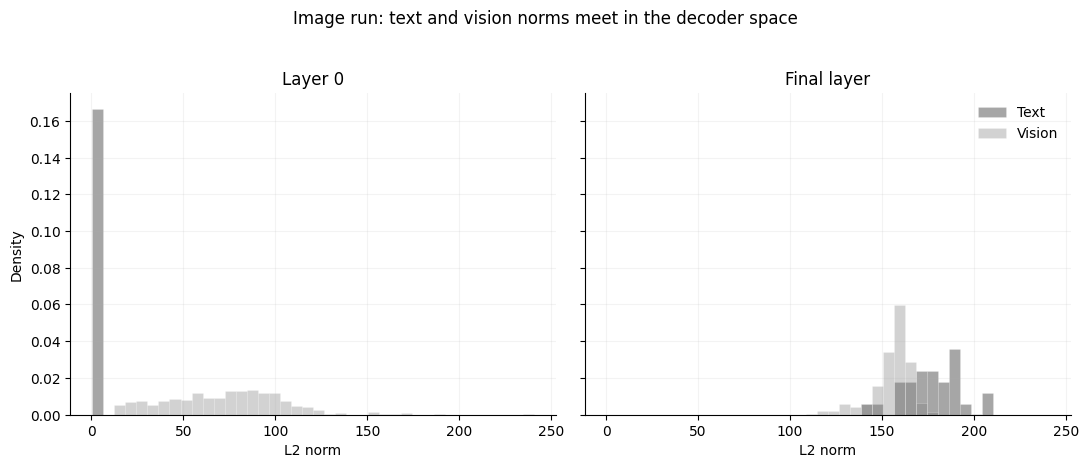

In [ ]:

conversation_img = [
    {"role": "user", "content": [
        {"type": "image", "image": frame_path},
        {"type": "text", "text": "Describe this frame from the video."},
    ]}
]

inputs_img = build_inputs(conversation_img, use_audio_in_video=False)
show_inputs(inputs_img, "IMAGE plus TEXT processor output")

ids_img, text_img, vision_img, audio_img = masks_from_inputs(inputs_img)

print("\nCounts (image run)")
print("  seq_len:", int(ids_img.shape[0]))
print("  Text:", int(text_img.sum().cpu()))
print("  Vision (<|IMAGE|>):", int(vision_img.sum().cpu()))
print("  Audio (<|AUDIO|>):", int(audio_img.sum().cpu()))

print("\nModel output")
print(generate_answer_only(inputs_img, max_new_tokens=192))

hs_img = forward_hidden_states(inputs_img)
h0_img = hs_img[0][0]
hf_img = hs_img[-1][0]

norms_img = {
    "Text":  {"L0": collect_norms(h0_img, text_img),   "Final": collect_norms(hf_img, text_img)},
    "Vision":{"L0": collect_norms(h0_img, vision_img), "Final": collect_norms(hf_img, vision_img)},
}

plot_norm_histograms(norms_img, title="Image run: text and vision norms meet in the decoder space")

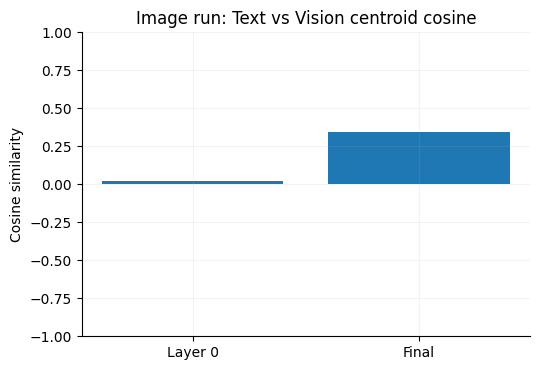

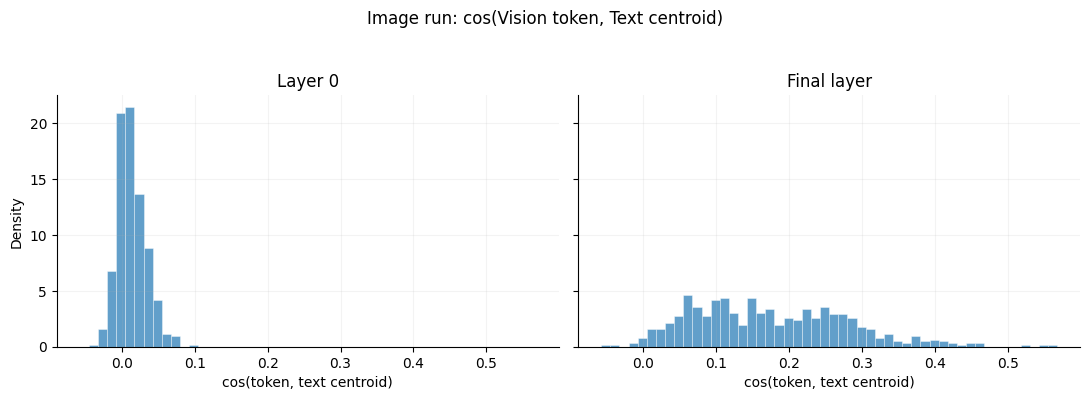

In [ ]:

h0 = hs_img[0][0]
hf = hs_img[-1][0]

text_c0  = centroid_direction(h0, text_img)
vis_c0   = centroid_direction(h0, vision_img)
text_cf  = centroid_direction(hf, text_img)
vis_cf   = centroid_direction(hf, vision_img)

c0 = cosine(text_c0, vis_c0)
cf = cosine(text_cf, vis_cf)

plot_centroid_cosines(
    "Image run: Text vs Vision centroid cosine",
    ["Layer 0", "Final"],
    [c0, cf],
)

# token wise sims: vision token vs text centroid at each layer
vis_sims_l0    = token_to_centroid_cosines(h0, vision_img, text_c0)
vis_sims_final = token_to_centroid_cosines(hf, vision_img, text_cf)

plot_token_cosine_hists(
    "Image run: cos(Vision token, Text centroid)",
    vis_sims_l0,
    vis_sims_final,
)

# Video with audio plus text: run 3 queries (transcribe, gender, sentiment)

qwen-vl-utils using torchcodec to read video.



Transcription
Prompt: Transcribe the speech in this video.
Answer: If you want to know how to build this, join me for this hands-on multimodal AI life course.



Gender
Prompt: Classify the speaker voice as male or female. Answer with one word only.
Answer: Female

Sentiment
Prompt: Classify the speaker sentiment as positive, negative, or neutral. Answer with one word only.
Answer: Positive

VIDEO with AUDIO plus TEXT processor output (last run)
input_ids                    shape=         (1, 2656)  dtype=torch.int64
attention_mask               shape=         (1, 2656)  dtype=torch.int64
pixel_values_videos          shape=      (9920, 1176)  dtype=torch.bfloat16
video_grid_thw               shape=            (1, 3)  dtype=torch.int64
video_second_per_grid        shape=              (1,)  dtype=torch.bfloat16
feature_attention_mask       shape=        (1, 30000)  dtype=torch.int32
input_features               shape=   (1, 128, 30000)  dtype=torch.bfloat16

Counts (audio run)
  seq_len: 2656
  Text: 2522
  Vision (<|IMAGE|>): 0
  Audio (<|AUDIO|>): 134


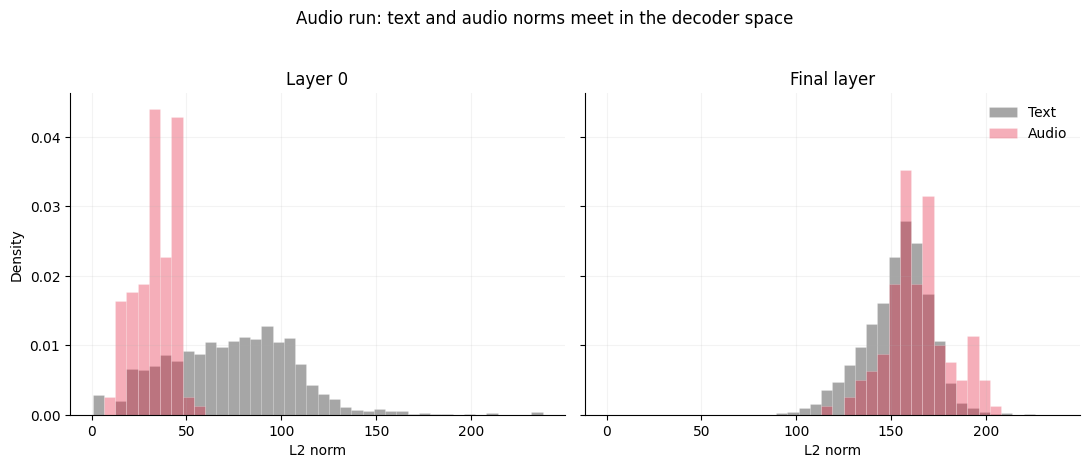

In [ ]:

USE_AUDIO_IN_VIDEO = True

def run_video_query(question, max_new_tokens=256):
    conversation = [
        {"role": "user", "content": [
            {"type": "video", "video": video_path},
            {"type": "text", "text": question},
        ]}
    ]
    inputs = build_inputs(conversation, use_audio_in_video=USE_AUDIO_IN_VIDEO)
    answer = generate_answer_only(inputs, max_new_tokens=max_new_tokens)
    return inputs, answer

queries = [
    ("Transcription", "Transcribe the speech in this video."),
    ("Gender", "Classify the speaker voice as male or female. Answer with one word only."),
    ("Sentiment", "Classify the speaker sentiment as positive, negative, or neutral. Answer with one word only."),
]

for name, q in queries:
    inputs_tmp, ans = run_video_query(q, max_new_tokens=256)
    print("\n" + "=" * 72)
    print(name)
    print("=" * 72)
    print("Prompt:", q)
    print("Answer:", ans)

# Use the last run for hidden state inspection and plots
inputs_aud = inputs_tmp

show_inputs(inputs_aud, "VIDEO with AUDIO plus TEXT processor output (last run)")
ids_aud, text_aud, vision_aud, audio_aud = masks_from_inputs(inputs_aud)

print("\nCounts (audio run)")
print("  seq_len:", int(ids_aud.shape[0]))
print("  Text:", int(text_aud.sum().cpu()))
print("  Vision (<|IMAGE|>):", int(vision_aud.sum().cpu()))
print("  Audio (<|AUDIO|>):", int(audio_aud.sum().cpu()))

hs_aud = forward_hidden_states(inputs_aud)
h0_aud = hs_aud[0][0]
hf_aud = hs_aud[-1][0]

norms_aud = {
    "Text": {"L0": collect_norms(h0_aud, text_aud), "Final": collect_norms(hf_aud, text_aud)},
    "Audio":{"L0": collect_norms(h0_aud, audio_aud), "Final": collect_norms(hf_aud, audio_aud)},
}

plot_norm_histograms(norms_aud, title="Audio run: text and audio norms meet in the decoder space")

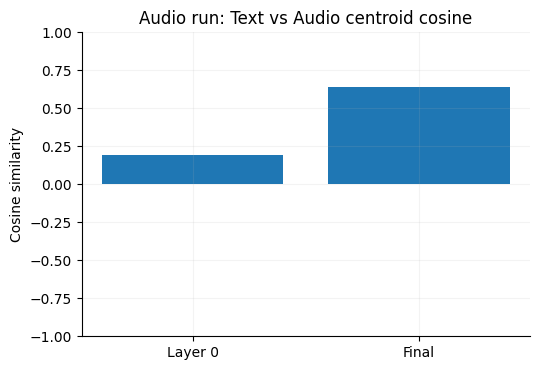

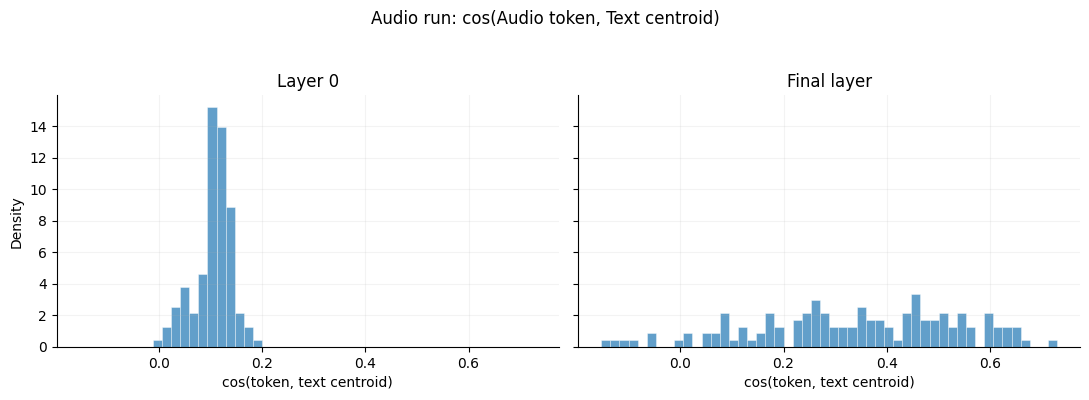

In [ ]:

h0 = hs_aud[0][0]
hf = hs_aud[-1][0]

text_c0  = centroid_direction(h0, text_aud)
aud_c0   = centroid_direction(h0, audio_aud)
text_cf  = centroid_direction(hf, text_aud)
aud_cf   = centroid_direction(hf, audio_aud)

c0 = cosine(text_c0, aud_c0)
cf = cosine(text_cf, aud_cf)

plot_centroid_cosines(
    "Audio run: Text vs Audio centroid cosine",
    ["Layer 0", "Final"],
    [c0, cf],
)

aud_sims_l0    = token_to_centroid_cosines(h0, audio_aud, text_c0)
aud_sims_final = token_to_centroid_cosines(hf, audio_aud, text_cf)

plot_token_cosine_hists(
    "Audio run: cos(Audio token, Text centroid)",
    aud_sims_l0,
    aud_sims_final,
)

# Combined plot across modalities (explicitly mixed runs)

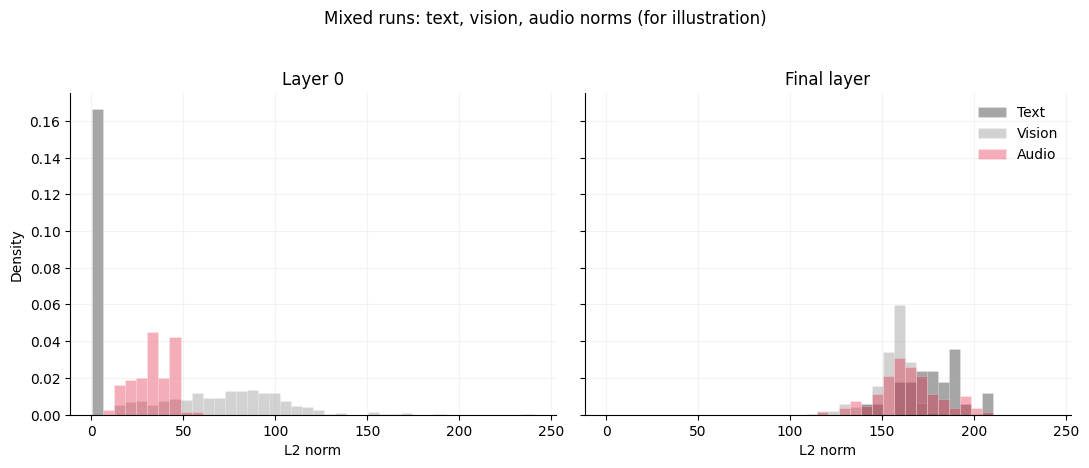

In [ ]:

norms_mixed = {
    "Text":  norms_img["Text"],      # from image run
    "Vision": norms_img["Vision"],   # from image run
    "Audio": norms_aud["Audio"],     # from audio run
}
plot_norm_histograms(norms_mixed, title="Mixed runs: text, vision, audio norms (for illustration)")


In [ ]:

def cosine(u: torch.Tensor, v: torch.Tensor, eps: float = 1e-8) -> float:
    u = u.float()
    v = v.float()
    return float(torch.dot(u, v) / (u.norm() * v.norm() + eps))

def centroid_direction(h_2d: torch.Tensor, mask_1d: torch.Tensor) -> torch.Tensor:
    x = h_2d[mask_1d]
    if x.numel() == 0:
        raise ValueError("Mask selects zero tokens, cannot form centroid.")
    return x.float().mean(dim=0)

def plot_alignment_curve(
    hs_tuple,
    text_mask,
    vision_mask=None,
    audio_mask=None,
    drop_last_layer=True,
    title="Meet in the middle: layer by layer fusion curve",
):
    """
    hs_tuple: tuple of hidden states, each is [batch, seq_len, hidden]
    masks:    [seq_len] boolean masks built from the same inputs that produced hs_tuple
    """

    n_layers_total = len(hs_tuple)
    n_layers_used = n_layers_total - 1 if drop_last_layer else n_layers_total
    layers_used = list(range(n_layers_used))

    vis_sims = []
    aud_sims = []

    for l in layers_used:
        h = hs_tuple[l][0]  # [seq_len, hidden]

        text_c = centroid_direction(h, text_mask)

        if vision_mask is not None and int(vision_mask.sum().item()) > 0:
            vis_c = centroid_direction(h, vision_mask)
            vis_sims.append(cosine(text_c, vis_c))

        if audio_mask is not None and int(audio_mask.sum().item()) > 0:
            aud_c = centroid_direction(h, audio_mask)
            aud_sims.append(cosine(text_c, aud_c))

    fig, ax = plt.subplots(figsize=(10, 5))

    if vision_mask is not None and int(vision_mask.sum().item()) > 0:
        ax.plot(
            layers_used,
            vis_sims,
            label="Vision vs Text",
            color="#808080",
            marker="o",
            markersize=4,
            linewidth=2,
        )

    if audio_mask is not None and int(audio_mask.sum().item()) > 0:
        ax.plot(
            layers_used,
            aud_sims,
            label="Audio vs Text",
            color="#E51837",
            marker="s",
            markersize=4,
            linewidth=2,
        )

    ax.set_xlabel("Layer index")
    ax.set_ylabel("Cosine similarity")
    ax.set_title(title)
    ax.grid(True, alpha=0.15)
    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

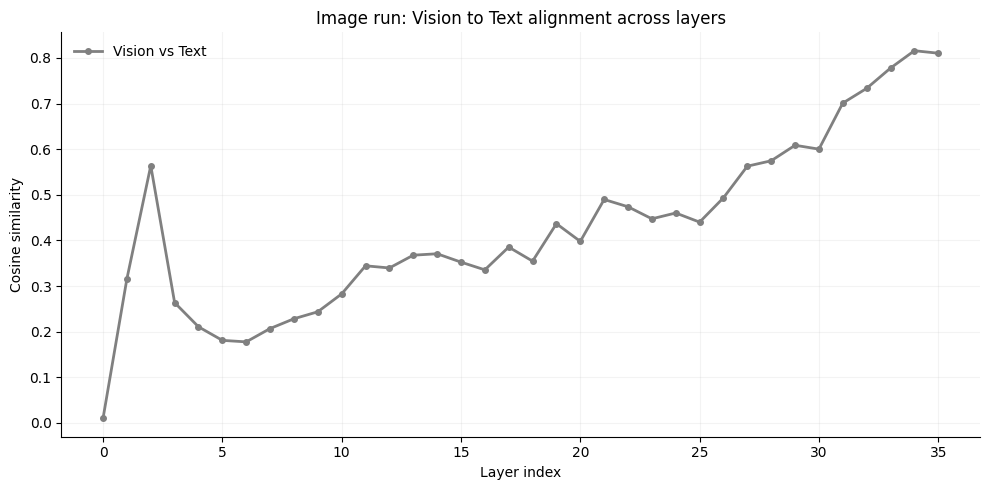

In [ ]:

hs_img = forward_hidden_states(inputs_img)
ids_img, text_img, vision_img, audio_img = masks_from_inputs(inputs_img)

plot_alignment_curve(
    hs_img,
    text_mask=text_img,
    vision_mask=vision_img,
    audio_mask=None,
    drop_last_layer=True,
    title="Image run: Vision to Text alignment across layers",
)

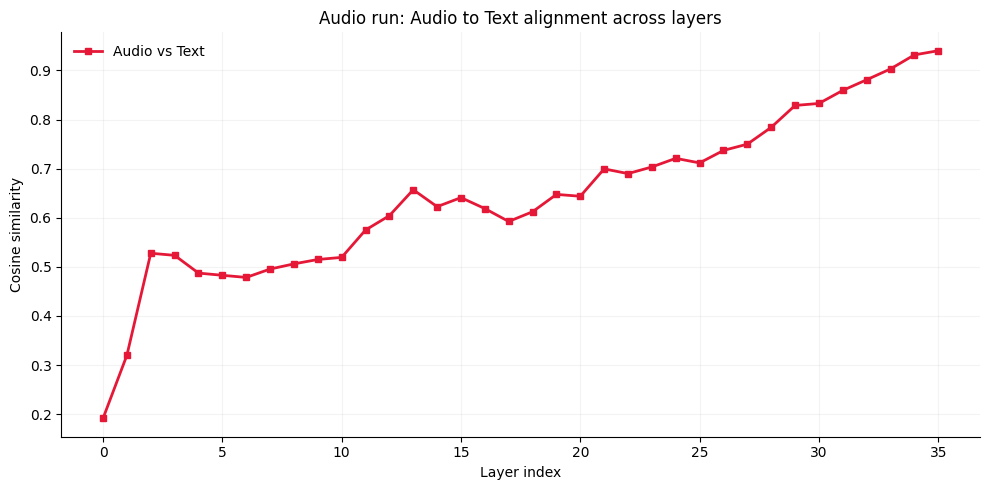

In [ ]:

hs_aud = forward_hidden_states(inputs_aud)
ids_aud, text_aud, vision_aud, audio_aud = masks_from_inputs(inputs_aud)

plot_alignment_curve(
    hs_aud,
    text_mask=text_aud,
    vision_mask=None,
    audio_mask=audio_aud,
    drop_last_layer=True,
    title="Audio run: Audio to Text alignment across layers",
)

In [ ]:
def plot_alignment_delta_curve(
    hs_tuple,
    text_mask,
    modality_mask,
    title="Alignment delta per layer",
    drop_last_layer=True,
):

    n_layers_total = len(hs_tuple)
    n_layers_used = n_layers_total - 1 if drop_last_layer else n_layers_total
    layers = list(range(n_layers_used))

    sims = []

    for l in layers:
        h = hs_tuple[l][0]  # [seq_len, hidden]

        t = centroid_direction(h, text_mask)
        m = centroid_direction(h, modality_mask)

        sims.append(cosine(t, m))

    sims = np.array(sims, dtype=np.float32)

    # layer-to-layer change
    delta = np.diff(sims)

    fig, ax = plt.subplots(figsize=(10, 3.6))

    ax.plot(
        np.arange(1, len(sims)),
        delta,
        marker="o",
        markersize=3,
        linewidth=2,
        color="#E51837",
    )

    ax.axhline(0.0, color="black", alpha=0.2)

    ax.set_xlabel("Layer index")
    ax.set_ylabel("Δ cosine")
    ax.set_title(title)
    ax.grid(True, alpha=0.15)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

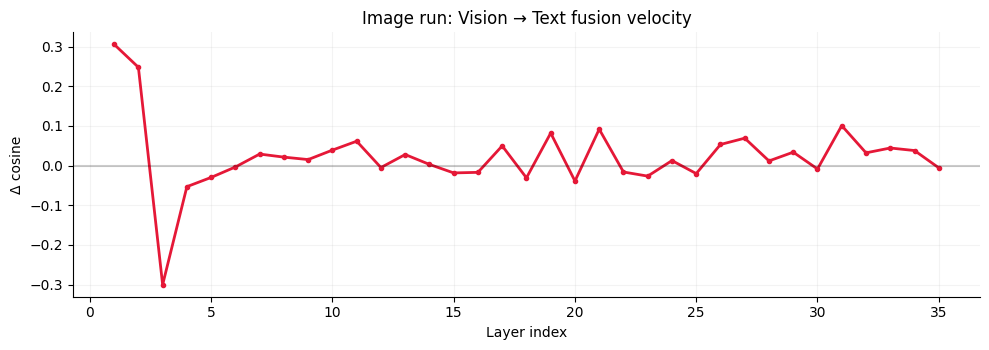

In [ ]:
plot_alignment_delta_curve(
    hs_img,
    text_mask=text_img,
    modality_mask=vision_img,
    title="Image run: Vision → Text fusion velocity",
)

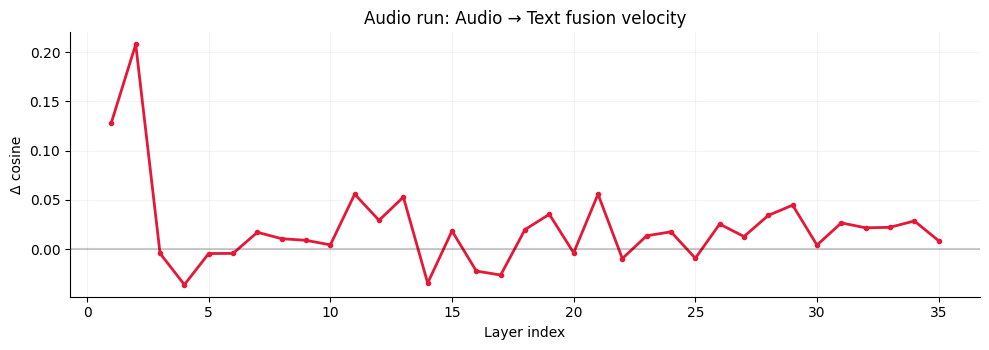

In [ ]:
plot_alignment_delta_curve(
    hs_aud,
    text_mask=text_aud,
    modality_mask=audio_aud,
    title="Audio run: Audio → Text fusion velocity",
)

In [ ]:

def plot_alignment_cumulative_curve(
    hs_tuple,
    text_mask,
    modality_mask,
    title="Cumulative alignment trajectory",
    drop_last_layer=True,
):
    sims = []
    n_layers = len(hs_tuple) - 1 if drop_last_layer else len(hs_tuple)

    for l in range(n_layers):
        h = hs_tuple[l][0]
        t = centroid_direction(h, text_mask)
        m = centroid_direction(h, modality_mask)
        sims.append(cosine(t, m))

    sims = np.array(sims, dtype=np.float32)
    delta = np.diff(sims)
    cumulative = np.cumsum(delta)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(
        np.arange(1, len(sims)),
        cumulative,
        linewidth=2,
        color="#000000",
    )

    ax.axhline(0.0, color="black", alpha=0.2)
    ax.set_xlabel("Layer index")
    ax.set_ylabel("Cumulative Δ cosine")
    ax.set_title(title)
    ax.grid(True, alpha=0.15)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

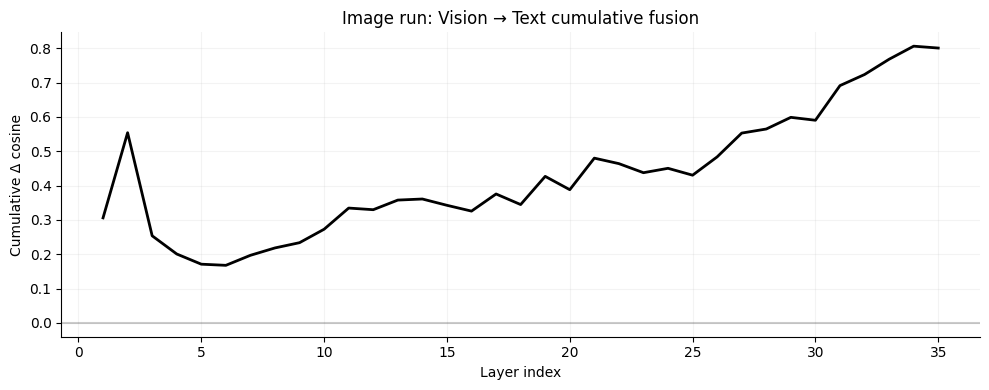

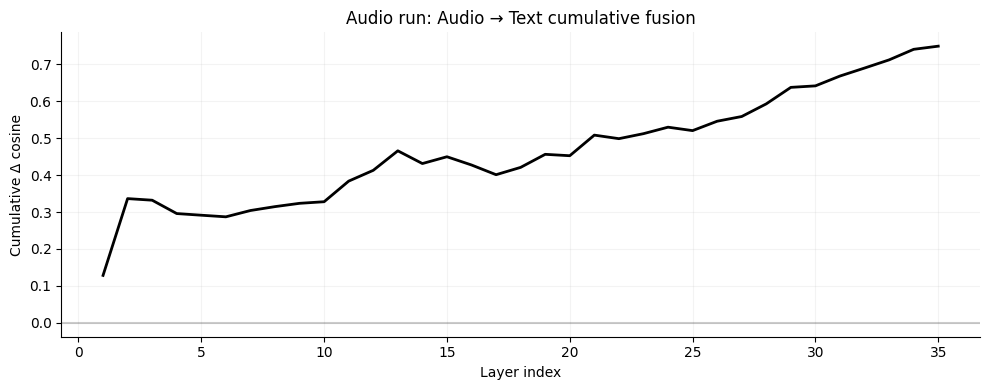

In [ ]:
plot_alignment_cumulative_curve(
    hs_img,
    text_mask=text_img,
    modality_mask=vision_img,
    title="Image run: Vision → Text cumulative fusion",
)

plot_alignment_cumulative_curve(
    hs_aud,
    text_mask=text_aud,
    modality_mask=audio_aud,
    title="Audio run: Audio → Text cumulative fusion",
)

## What these curves mean


> cumulative sum of Δ cosine(Text centroid, Modality centroid)

So this is literally:

**how much alignment has accumulated as we move through the decoder stack.**

Think of it as:

* slope = fusion velocity
* height = total fusion achieved so far

---

## Vision → Text

Key features in the curve:

### 1. Big jump in layers 0-2

You see a sharp early rise:

That is **encoder injection + early cross attention projection.**

This is where:

* vision encoder outputs
* get linearly projected
* injected into token slots
* and immediately pulled toward text space.

This is expected and healthy.

This is the “modal grounding” phase.

---

### 2. Flat middle (roughly layers ~4-18)

The curve almost plateaus here.

That tells you:

> Once projected, vision just rides along in the shared latent space.

This region is dominated by:

* language modeling
* reasoning
* composition

Not modality alignment.

This is the **shared semantic backbone.**

---

### 3. Late rise (layers ~25+)

You see another gradual climb near the end.

That's decoder-side semantic sharpening:

* preparing outputs
* tightening alignment for generation
* pulling everything into token-prediction geometry

This is typical for LLMs.

---

## Audio → Text

Audio shows the same structure, but softer:

* smaller initial spike
* smoother accumulation
* slower late convergence

Which matches intuition:

Audio embeddings are temporally noisier than vision patches.

So fusion is more distributed.

Still:

Same phases:

1. Early projection
2. Shared latent processing
3. Late decoding alignment

---

## Conceptual takeaway

This demonstrates:

### Multimodal fusion is NOT gradual across all layers.

It happens in **three phases**:

```
Encoder projection  →  Shared reasoning  →  Decoder alignment
```

Or visually:

```
jump → plateau → slow rise
```

That's textbook “meet in the middle”.

---

## Short grounding on the other plots

* Norms → “they live in same space”
* Cosine → “they point in same direction”
* Delta → “where fusion happens”
* Cumulative → “how much fusion is done by layer k”

